### Tutorial of dGbyG

dGbyG provides two main classes:
- **`Compound`** – represents a chemical compound and its thermodynamic properties
- **`Reaction`** – represents a chemical reaction and computes the standard Gibbs energy change

---

## 1. Compound

### 1.1 Creating a Compound

You can create a `Compound` from various identifier types:

────────────────────────────────────────────────────────────
                          化合物对象                           
────────────────────────────────────────────────────────────
SMILES:    O=C(CO)COP(=O)(O)O
InChI:     InChI=1S/C3H7O6P/c4-1-3(5)2-9-10(6,7)8/h4H,1-2H2,(H2,6,7,8)
InChIKey:  GNGACRATGGDKBX-UHFFFAOYSA-N
Δ_fG'°:    -1091.7 ± 0.5 kJ/mol
Has pKa:    Yes
────────────────────────────────────────────────────────────
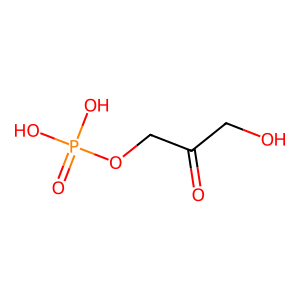

In [19]:
from dGbyG.api import Compound

# From SMILES
comp = Compound('O=C(CO)COP(=O)(O)O', 'smiles')
comp

The supported identifier types (`cid_type`) are:

In [20]:
print(Compound.recognizable_cids)

['inchi', 'smiles', 'file', 'kegg', 'kegg.compound', 'metanetx', 'metanetx.chemical', 'hmdb', 'chebi', 'lipidmaps', 'lipid maps', 'pubchem', 'pubchem.compound', 'recon3d', 'inchi-key', 'inchi_key', 'inchi key', 'inchikey', 'bigg', 'bigg.metabolite', 'name']


────────────────────────────────────────────────────────────
                          化合物对象                           
────────────────────────────────────────────────────────────
SMILES:    O=C(CO)COP(=O)(O)O
InChI:     InChI=1S/C3H7O6P/c4-1-3(5)2-9-10(6,7)8/h4H,1-2H2,(H2,6,7,8)
InChIKey:  GNGACRATGGDKBX-UHFFFAOYSA-N
Δ_fG'°:    -1091.7 ± 0.5 kJ/mol
Has pKa:    Yes
────────────────────────────────────────────────────────────
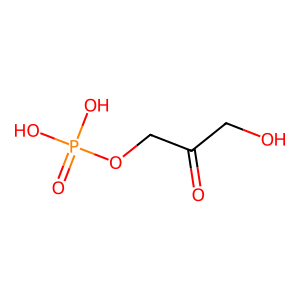

In [21]:
# From KEGG compound ID
comp_kegg = Compound('C00111', 'kegg')
comp_kegg

────────────────────────────────────────────────────────────
                          化合物对象                           
────────────────────────────────────────────────────────────
SMILES:    O=C[C@H](O)COP(=O)(O)O
InChI:     InChI=1S/C3H7O6P/c4-1-3(5)2-9-10(6,7)8/h1,3,5H,2H2,(H2,6,7,8)/t3-/m0/s1
InChIKey:  LXJXRIRHZLFYRP-VKHMYHEASA-N
Δ_fG'°:    -1086.5 ± 0.6 kJ/mol
Has pKa:    Yes
────────────────────────────────────────────────────────────
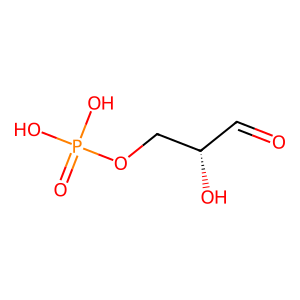

In [22]:
# From compound name
comp_name = Compound('D-Glyceraldehyde 3-phosphate', 'name')
comp_name

### 1.2 Molecular Identifiers

Once created, you can access various molecular identifiers:

In [23]:
comp = Compound('O=C(CO)COP(=O)(O)O', 'smiles')

print(f'SMILES:   {comp.Smiles}')
print(f'InChI:    {comp.InChI}')
print(f'InChIKey: {comp.InChIKey}')

SMILES:   O=C(CO)COP(=O)(O)O
InChI:    InChI=1S/C3H7O6P/c4-1-3(5)2-9-10(6,7)8/h4H,1-2H2,(H2,6,7,8)
InChIKey: GNGACRATGGDKBX-UHFFFAOYSA-N


You can also get the atom composition (atom bag) of the compound:

In [24]:
print('Atom bag:', comp.atom_bag)

Atom bag: {'O': 6, 'C': 3, 'P': 1, 'H': 7, 'charge': 0}


### 1.3 Thermodynamic Properties

The standard formation Gibbs energy (ΔfG'°) is predicted by the dGbyG model:

In [25]:
dGf_mean, dGf_std = comp.standard_dGf_prime
print(f"Standard formation Gibbs energy: {dGf_mean:.1f} +/- {dGf_std:.1f} kJ/mol")

Standard formation Gibbs energy: -1091.7 +/- 0.5 kJ/mol


### 1.4 pKa and Transformability

You can check whether a compound has pKa data available (required for pH-dependent transformations):

In [26]:
print(f'Can be transformed: {comp.can_be_transformed}')
print(f'pKa data: {comp.pKa()}')

Can be transformed: True
pKa data: {'acidicValuesByAtom': [{'atomIndex': 3, 'value': 13.797529636283945}, {'atomIndex': 4, 'value': 16.684841778757836}, {'atomIndex': 8, 'value': 6.219558776779401}, {'atomIndex': 9, 'value': 1.1916926489295263}], 'basicValuesByAtom': [{'atomIndex': 0, 'value': -8.434674005811425}, {'atomIndex': 3, 'value': -3.3206216372855866}]}


### 1.5 Conditional Thermodynamic Properties

By default, the compound uses standard biochemical conditions (pH=7.0, I=0.25, pMg=14.0, T=298.15 K). 
You can modify these conditions to get the **transformed** Gibbs energy at different pH, ionic strength, etc.:

In [27]:
# Default conditions
print('Default conditions:', comp.condition)
dGf_default = comp.transformed_standard_dGf_prime
print(f"Default dGf: {dGf_default[0]:.1f} +/- {dGf_default[1]:.1f} kJ/mol")

# Change pH to 6.0
comp.condition = {'pH': 6.0}
dGf_pH6 = comp.transformed_standard_dGf_prime
print(f"pH=6.0 dGf: {dGf_pH6[0]:.1f} +/- {dGf_pH6[1]:.1f} kJ/mol")

Default conditions: {'T': 298.15, 'pH': 7.0, 'I': 0.25, 'pMg': 14.0, 'e_potential': 0.0}
Default dGf: -1091.7 +/- 0.5 kJ/mol
pH=6.0 dGf: -1122.3 +/- 0.5 kJ/mol


### 1.6 Concentration and Real Gibbs Energy

You can set the compound concentration to compute the **actual** (non-standard) Gibbs energy of formation, which includes the concentration term:

dGf' = dGf'° + RT·ln([C])

Concentration can be set directly or via the logarithmic `z` property (where z = log10(concentration)):

In [28]:
comp = Compound('O=C(CO)COP(=O)(O)O', 'smiles')

# Default: concentration = 1 M (standard state)
print(f'Default concentration: {comp.concentration} M, z = {comp.z}')
dGf_std = comp.transformed_standard_dGf_prime
print(f"Standard dGf: {dGf_std[0]:.1f} kJ/mol")

# Set concentration to 0.001 M (1 mM)
comp.concentration = 0.001
print(f'Concentration: {comp.concentration} M, z = {comp.z}')
dGf_actual = comp.transformed_dGf_prime
print(f"Actual dGf: {dGf_actual[0]:.1f} kJ/mol")

# Alternatively, set via z (log10 scale)
comp.z = -3  # concentration = 10^-3 = 0.001 M
print(f'z = {comp.z}, concentration = {comp.concentration} M')

Default concentration: 1 M, z = 0
Standard dGf: -1091.7 kJ/mol
Concentration: 0.001 M, z = -3.0
Actual dGf: -1108.8 kJ/mol
z = -3, concentration = 0.001 M


### 1.7 Molecular Image

You can display the 2D structure of the compound:

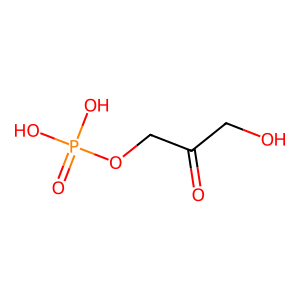

In [29]:
comp.image

---

## 2. Reaction

### 2.1 Creating a Reaction

You can create a `Reaction` from an equation string with a uniform identifier type:

In [30]:
from dGbyG.api import Reaction

# From SMILES equation
equation = 'O=P(O)(O)OC[C@H]1OC(O)(COP(=O)(O)O)[C@@H](O)[C@@H]1O = O=C(CO)COP(=O)(O)O + [H]C(=O)[C@H](O)COP(=O)(O)O'
reaction = Reaction(equation, cids_type='SMILES')
reaction

──────────────────────────────────────────────────
               Chemical Reaction                
──────────────────────────────────────────────────
Equation:       O=P(O)(O)OC[C@H]1OC(O)(COP(=O)(O)O)[C@@H](O)[C@@H]1O → O=C(CO)COP(=O)(O)O + O=C[C@H](O)COP(=O)(O)O
Is Balanced:         ✅ Yes
Δ<sub>r</sub>G'°:          22.1 ± 0.6 kJ/mol
──────────────────────────────────────────────────

In [31]:
# From KEGG compound IDs
equation = 'C00354 <=> C00111 + C00118'
reaction_kegg = Reaction(equation, cids_type='kegg')

std_dG, unc = reaction_kegg.transformed_standard_dGr_prime
print(f"dGr: {std_dG:.2f} +/- {unc:.2f} kJ/mol")

dGr: 22.07 +/- 0.56 kJ/mol


In [32]:
# From compound names
equation = 'D-Fructose 1,6-bisphosphate <=> Glycerone phosphate + D-Glyceraldehyde 3-phosphate'
reaction_name = Reaction(equation, cids_type='name')

std_dG, unc = reaction_name.transformed_standard_dGr_prime
print(f"dGr: {std_dG:.2f} +/- {unc:.2f} kJ/mol")

dGr: 22.07 +/- 0.56 kJ/mol


### 2.2 Mixed Identifier Types

When metabolites use different identifier types, pass them in the format `cidtype:cid`:

In [33]:
# With different metabolites IDs
equation = 'CHEBI:37736 = SMILES:O=C(CO)COP(=O)(O)O + name:D-Glyceraldehyde 3-phosphate'
reaction_mixed = Reaction(equation)
reaction_mixed

──────────────────────────────────────────────────
               Chemical Reaction                
──────────────────────────────────────────────────
Equation:       O=P(O)(O)OC[C@H]1OC(O)(COP(=O)(O)O)[C@@H](O)[C@@H]1O → O=C(CO)COP(=O)(O)O + O=C[C@H](O)COP(=O)(O)O
Is Balanced:         ✅ Yes
Δ<sub>r</sub>G'°:          22.1 ± 0.6 kJ/mol
──────────────────────────────────────────────────

### 2.3 Creating a Reaction from a Dict

You can also create a `Reaction` from a dictionary of `{Compound: coefficient}`, where negative coefficients are substrates and positive coefficients are products:

In [34]:
comp1 = Compound('O=P(O)(O)OC[C@H]1OC(O)(COP(=O)(O)O)[C@@H](O)[C@@H]1O', 'smiles')
comp2 = Compound('O=C(CO)COP(=O)(O)O', 'smiles')
comp3 = Compound('O=C[C@H](O)COP(=O)(O)O', 'smiles')

reaction_dict = Reaction({comp1: -1, comp2: 1, comp3: 1})
reaction_dict

──────────────────────────────────────────────────
               Chemical Reaction                
──────────────────────────────────────────────────
Equation:       O=P(O)(O)OC[C@H]1OC(O)(COP(=O)(O)O)[C@@H](O)[C@@H]1O → O=C(CO)COP(=O)(O)O + O=C[C@H](O)COP(=O)(O)O
Is Balanced:         ✅ Yes
Δ<sub>r</sub>G'°:          22.1 ± 0.6 kJ/mol
──────────────────────────────────────────────────

### 2.4 Reaction Identifiers

You can access the reaction equation in different formats:

In [35]:
# Reaction as a dict of {SMILES: coefficient}
print('rxnSmiles:', reaction.rxnSmiles)

# Reaction equation in SMILES format
print('equationSmiles:', reaction.equationSmiles())

# Optionally remove H+ from the equation display
print('equationSmiles (remove H+):', reaction.equationSmiles(remove_H_ion=True))

# Reaction equation in InChI format
print('equiationInChI:', reaction.equiationInChI())

rxnSmiles: {'O=P(O)(O)OC[C@H]1OC(O)(COP(=O)(O)O)[C@@H](O)[C@@H]1O': -1, 'O=C(CO)COP(=O)(O)O': 1, 'O=C[C@H](O)COP(=O)(O)O': 1}
equationSmiles: O=P(O)(O)OC[C@H]1OC(O)(COP(=O)(O)O)[C@@H](O)[C@@H]1O = O=C(CO)COP(=O)(O)O + O=C[C@H](O)COP(=O)(O)O
equationSmiles (remove H+): O=P(O)(O)OC[C@H]1OC(O)(COP(=O)(O)O)[C@@H](O)[C@@H]1O = O=C(CO)COP(=O)(O)O + O=C[C@H](O)COP(=O)(O)O
equiationInChI: InChI=1S/C6H14O12P2/c7-4-3(1-16-19(10,11)12)18-6(9,5(4)8)2-17-20(13,14)15/h3-5,7-9H,1-2H2,(H2,10,11,12)(H2,13,14,15)/t3-,4-,5+,6?/m1/s1 = InChI=1S/C3H7O6P/c4-1-3(5)2-9-10(6,7)8/h4H,1-2H2,(H2,6,7,8) + InChI=1S/C3H7O6P/c4-1-3(5)2-9-10(6,7)8/h1,3,5H,2H2,(H2,6,7,8)/t3-/m0/s1


### 2.5 Substrates and Products

Access the substrates (negative coefficients) and products (positive coefficients) of the reaction:

In [36]:
print('Substrates:')
for comp, coeff in reaction.substrates.items():
    print(f'  {comp.Smiles}: {coeff}')

print('Products:')
for comp, coeff in reaction.products.items():
    print(f'  {comp.Smiles}: {coeff}')

Substrates:
  O=P(O)(O)OC[C@H]1OC(O)(COP(=O)(O)O)[C@@H](O)[C@@H]1O: -1
Products:
  O=C(CO)COP(=O)(O)O: 1
  O=C[C@H](O)COP(=O)(O)O: 1


### 2.6 Reaction Balance

Check whether the reaction is atom-balanced and inspect the atom difference:

In [37]:
print(f'Is balanced: {reaction.is_balanced}')
print(f'Atom diff: {reaction.atom_diff}')

# For an unbalanced reaction, atom_diff shows which atoms are missing
reaction_ub = Reaction('O=C(CO)COP(=O)(O)O = O=C[C@H](O)COP(=O)(O)O + [H]O[H]', cids_type='smiles')
print(f'\nUnbalanced example - is balanced: {reaction_ub.is_balanced}')
print(f'Atom diff: {reaction_ub.atom_diff}')

Is balanced: True
Atom diff: {}

Unbalanced example - is balanced: False
Atom diff: {'O': 1, 'H': 2}


### 2.7 Thermodynamic Properties

The `Reaction` class provides three levels of Gibbs energy:
- **`standard_dGr_prime`** – Standard reaction Gibbs energy at default conditions (pH=7.0)
- **`transformed_standard_dGr_prime`** – Transformed standard Gibbs energy at custom conditions
- **`transformed_dGr_prime`** – Actual Gibbs energy including concentration effects

In [38]:
# Standard reaction Gibbs energy
std_dG, std_unc = reaction.standard_dGr_prime
print(f"Standard dGr: {std_dG:.2f} +/- {std_unc:.2f} kJ/mol")

# Transformed standard Gibbs energy (same as standard at default conditions)
trans_dG, trans_unc = reaction.transformed_standard_dGr_prime
print(f"Transformed standard dGr: {trans_dG:.2f} +/- {trans_unc:.2f} kJ/mol")

# Actual Gibbs energy (including concentration effects)
actual_dG, actual_unc = reaction.transformed_dGr_prime
print(f"Actual dGr: {actual_dG:.2f} +/- {actual_unc:.2f} kJ/mol")

Standard dGr: 22.07 +/- 0.56 kJ/mol
Transformed standard dGr: 22.07 +/- 0.56 kJ/mol
Actual dGr: 22.07 +/- 0.56 kJ/mol


### 2.8 Conditional Thermodynamic Properties

Just like `Compound`, you can modify the reaction conditions (pH, ionic strength, etc.) to see how the Gibbs energy changes:

In [39]:
# Default conditions
dG_default = reaction.transformed_standard_dGr_prime
print(f"Default pH=7.0: dGr = {dG_default[0]:.2f} kJ/mol")

# Change pH to 6.0
reaction.condition = {'pH': 6.0}
dG_pH6 = reaction.transformed_standard_dGr_prime
print(f"pH=6.0: dGr = {dG_pH6[0]:.2f} kJ/mol")

# Change ionic strength
reaction.condition = {'pH': 7.0, 'I': 0.1}
dG_I01 = reaction.transformed_standard_dGr_prime
print(f"pH=7.0, I=0.1: dGr = {dG_I01[0]:.2f} kJ/mol")

Default pH=7.0: dGr = 22.07 kJ/mol
pH=6.0: dGr = 21.61 kJ/mol
pH=7.0, I=0.1: dGr = 20.82 kJ/mol


### 2.9 pKa of Reaction Compounds

You can retrieve the pKa values for all compounds in the reaction:

In [40]:
reaction = Reaction('O=P(O)(O)OC[C@H]1OC(O)(COP(=O)(O)O)[C@@H](O)[C@@H]1O = O=C(CO)COP(=O)(O)O + [H]C(=O)[C@H](O)COP(=O)(O)O', cids_type='SMILES')

for comp, coeff in reaction.reaction.items():
    role = 'substrate' if coeff < 0 else 'product'
    print(f'{role}: {comp.Smiles}')
    print(f'  pKa: {comp.pKa()}')
    print()

substrate: O=P(O)(O)OC[C@H]1OC(O)(COP(=O)(O)O)[C@@H](O)[C@@H]1O
  pKa: {'acidicValuesByAtom': [{'atomIndex': 2, 'value': 6.519812810436834}, {'atomIndex': 3, 'value': 1.4949813769867828}, {'atomIndex': 9, 'value': 10.291242311813988}, {'atomIndex': 14, 'value': 5.915890500371595}, {'atomIndex': 15, 'value': 0.8908357002327183}, {'atomIndex': 17, 'value': 12.740698025621118}, {'atomIndex': 19, 'value': 14.164282076026485}], 'basicValuesByAtom': [{'atomIndex': 7, 'value': -4.419367225370367}, {'atomIndex': 9, 'value': -4.877371153241846}, {'atomIndex': 17, 'value': -4.030996430668296}, {'atomIndex': 19, 'value': -3.6844203047105473}]}

product: O=C(CO)COP(=O)(O)O
  pKa: {'acidicValuesByAtom': [{'atomIndex': 3, 'value': 13.797529636283945}, {'atomIndex': 4, 'value': 16.684841778757836}, {'atomIndex': 8, 'value': 6.219558776779401}, {'atomIndex': 9, 'value': 1.1916926489295263}], 'basicValuesByAtom': [{'atomIndex': 0, 'value': -8.434674005811425}, {'atomIndex': 3, 'value': -3.3206216372855